In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Unique Analysis: Tree visualization + Depth vs R2 overfitting curve
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Target-specific leakage-free feature sets (established in notebook 03)
FEATURES_SOLAR = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_VBAT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_TBATT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

tscv     = TimeSeriesSplit(n_splits=5)
splits   = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

datasets = {
    'Primary'  : (df[FEATURES_SOLAR], df[TARGET_PRIMARY],   FEATURES_SOLAR),
    'Secondary': (df[FEATURES_VBAT],  df[TARGET_SECONDARY], FEATURES_VBAT),
    'Tertiary' : (df[FEATURES_TBATT], df[TARGET_TERTIARY],  FEATURES_TBATT)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print(f"Targets    : {TARGET_PRIMARY}, {TARGET_SECONDARY}, {TARGET_TERTIARY}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876
Targets    : P_solar_total (µW), Vbat (V), Tbatt (℃)


In [3]:
# ============================================================
# SECTION 1: BASE MODEL — DEFAULT PARAMETERS
# Decision Tree splits using variance reduction (MSE criterion)
# No gradient optimization — pure recursive binary splitting
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — DEFAULT PARAMETERS (Before Tuning)")
print("Criterion: squared_error (variance reduction)")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results_before[name] = {
        'model' : model,
        'y_pred': y_pred,
        'y_test': y_test,
        'MSE'   : mse,
        'RMSE'  : rmse,
        'MAE'   : mae,
        'R2'    : r2,
        'feats' : feats,
        'depth' : model.get_depth(),
        'leaves': model.get_n_leaves()
    }

    print(f"\nTarget  : {y.name}")
    print(f"R2      : {r2:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"MSE     : {mse:.4f}")
    print(f"Tree Depth  : {model.get_depth()}")
    print(f"Tree Leaves : {model.get_n_leaves()}")

BASE MODEL — DEFAULT PARAMETERS (Before Tuning)
Criterion: squared_error (variance reduction)

Target  : P_solar_total (µW)
R2      : 0.8561
RMSE    : 335886.2811
MAE     : 194969.0450
MSE     : 112819593806.2610
Tree Depth  : 44
Tree Leaves : 17511

Target  : Vbat (V)
R2      : 0.8730
RMSE    : 0.0322
MAE     : 0.0200
MSE     : 0.0010
Tree Depth  : 39
Tree Leaves : 4673

Target  : Tbatt (℃)
R2      : -0.1607
RMSE    : 5.5859
MAE     : 3.5960
MSE     : 31.2024
Tree Depth  : 35
Tree Leaves : 6345


## Base Model Observations

### Overfitting Alert — Unconstrained Tree
The default Decision Tree with no depth constraints grew massively:

| Target | Depth | Leaves | Training Samples |
|--------|-------|--------|-----------------|
| P_solar_total | 44 | 17,511 | 19,383 |
| Vbat | 39 | 4,673 | 19,383 |
| Tbatt | 35 | 6,345 | 19,383 |

**P_solar_total has 17,511 leaves for 19,383 training samples — nearly one leaf per sample.**  
This is textbook memorization, not learning. The tree has essentially stored the training data rather than learning generalizable patterns.

> **Key Insight:** This demonstrates exactly why pruning parameters (`max_depth`, `min_samples_split`, `min_samples_leaf`) are critical for Decision Trees. Without them, the model achieves near-perfect train accuracy but fails on unseen data.

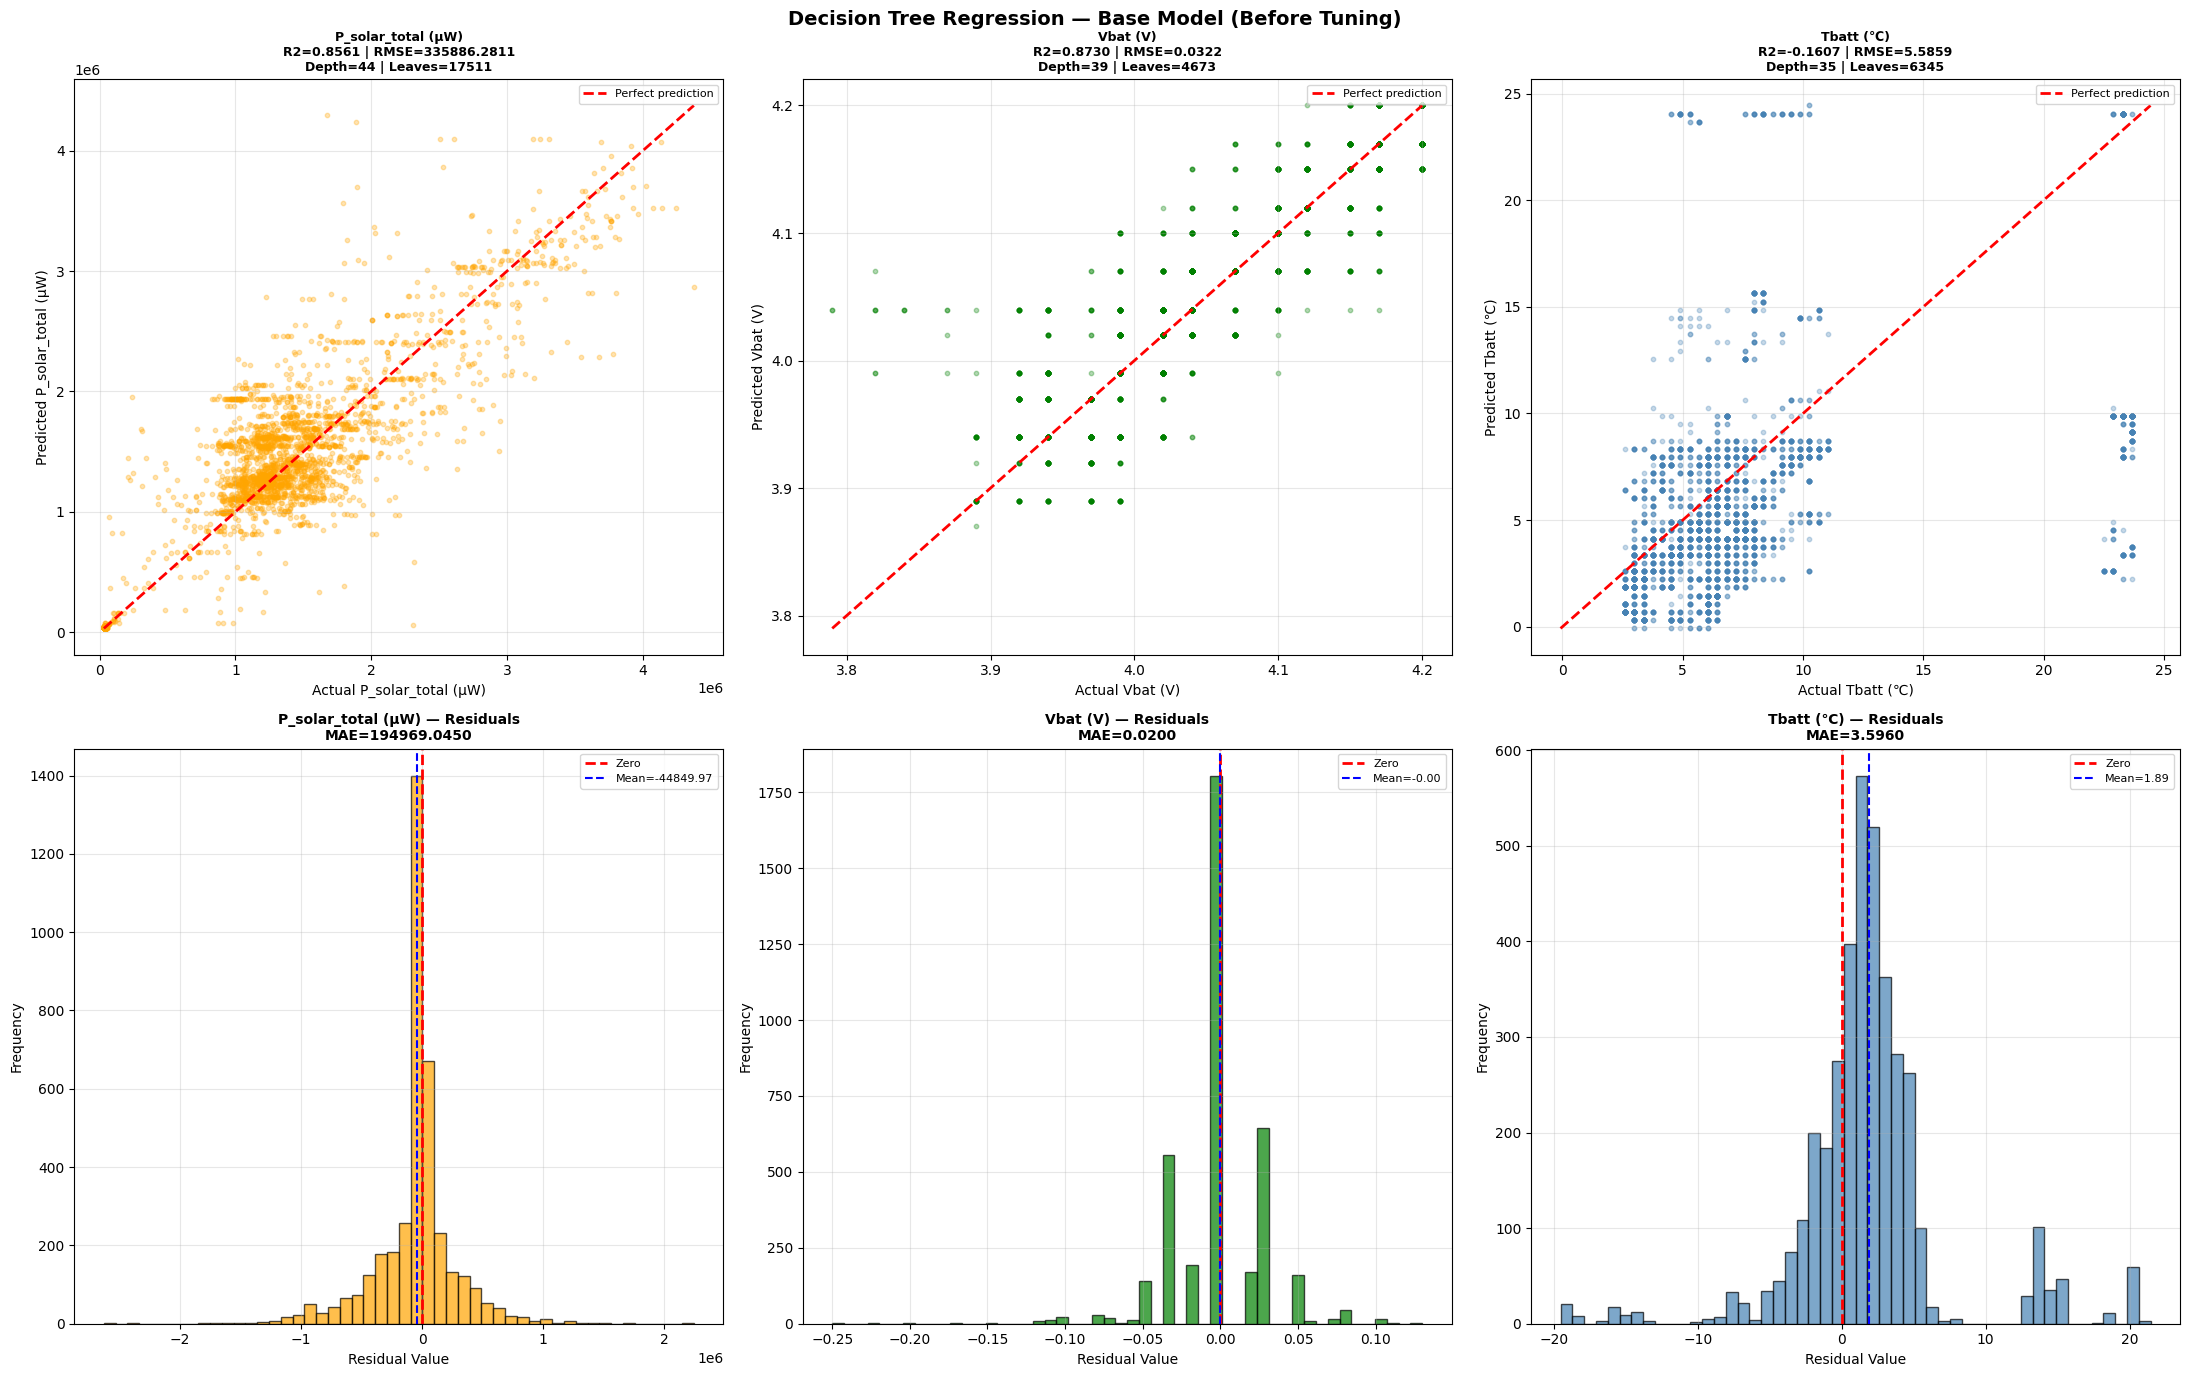

Base model plots saved.


In [4]:
# ============================================================
# SECTION 2: BASE MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Decision Tree Regression — Base Model (Before Tuning)',
             fontsize=14, fontweight='bold')

target_list = ['Primary', 'Secondary', 'Tertiary']
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors      = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(
        zip(target_list, y_targets, colors)):

    r      = results_before[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    # Row 1: Actual vs Predicted
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nR2={r["R2"]:.4f} | RMSE={r["RMSE"]:.4f}\n'
                 f'Depth={r["depth"]} | Leaves={r["leaves"]}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Residual Distribution
    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue', linestyle='--',
                linewidth=1.5, label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_base_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model plots saved.")

Testing max_depth 1 to 20...


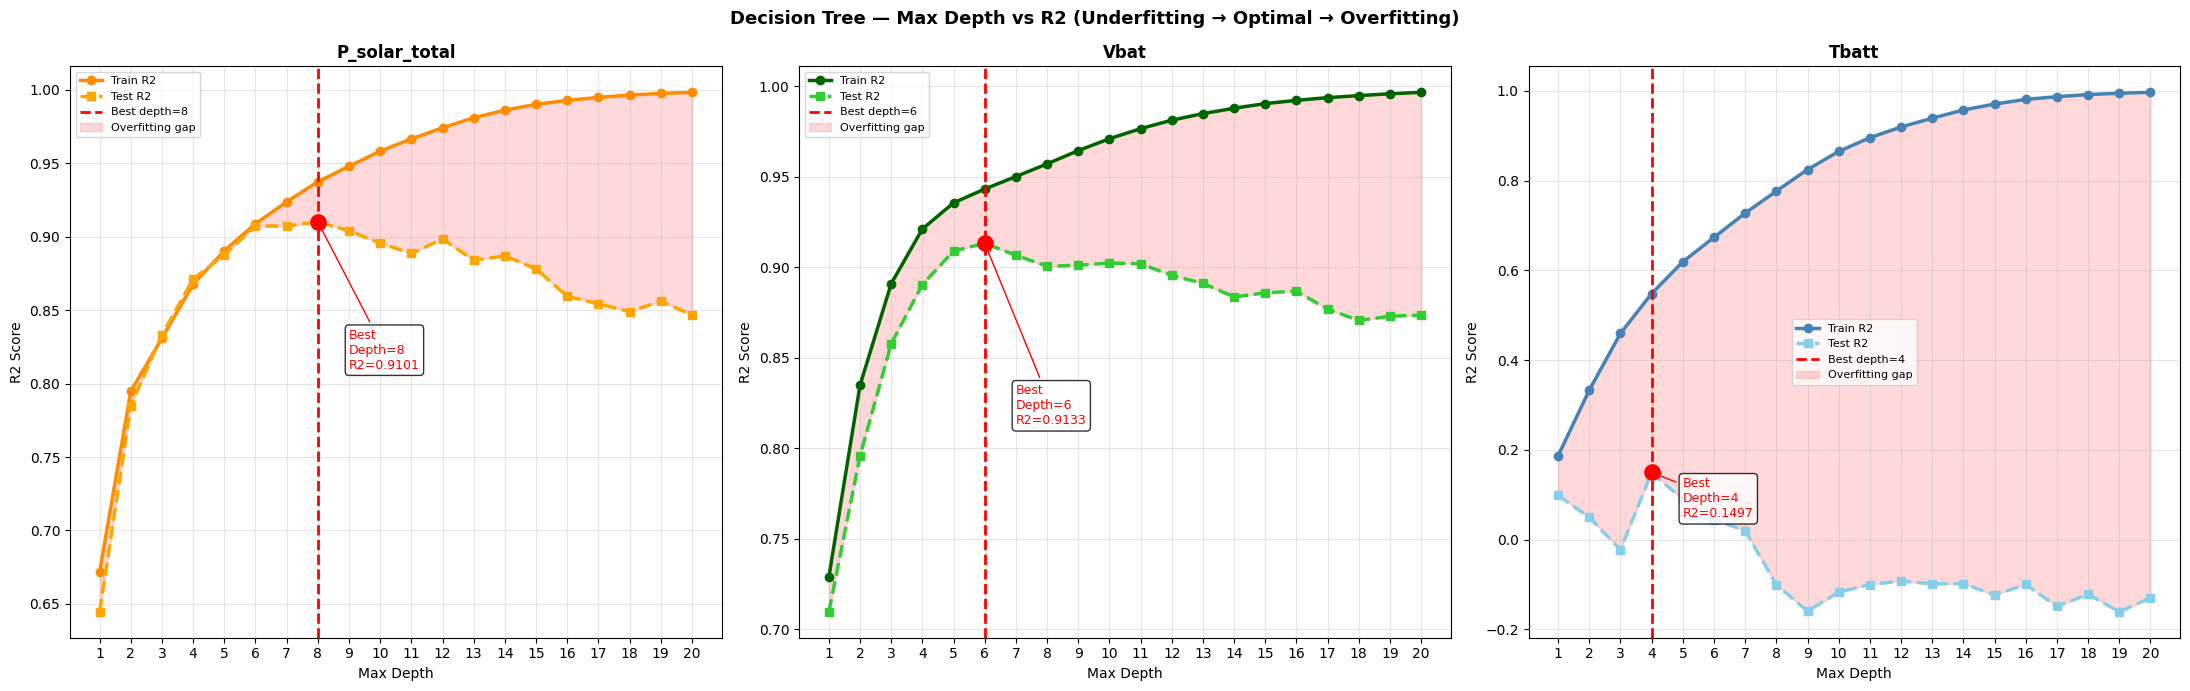

Depth vs R2 plot saved.


In [5]:
# ============================================================
# SECTION 3: UNIQUE ANALYSIS — DEPTH vs R2 OVERFITTING CURVE
# Shows underfitting → optimal → overfitting transition
# ============================================================

depths = range(1, 21)
depth_results = {name: {'train_r2': [], 'test_r2': []}
                 for name in datasets}

print("Testing max_depth 1 to 20...")

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    for d in depths:
        m = DecisionTreeRegressor(max_depth=d, random_state=42)
        m.fit(X_train, y_train)
        depth_results[name]['train_r2'].append(
            r2_score(y_train, m.predict(X_train)))
        depth_results[name]['test_r2'].append(
            r2_score(y_test, m.predict(X_test)))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Decision Tree — Max Depth vs R2 (Underfitting → Optimal → Overfitting)',
             fontsize=13, fontweight='bold')

colors_t = ['darkorange', 'darkgreen', 'steelblue']
colors_v = ['orange',     'limegreen', 'skyblue']
tnames   = ['P_solar_total', 'Vbat', 'Tbatt']

for idx, (name, ct, cv, tn) in enumerate(
        zip(datasets, colors_t, colors_v, tnames)):
    tr = depth_results[name]['train_r2']
    te = depth_results[name]['test_r2']
    best_d = list(depths)[np.argmax(te)]
    best_r2 = max(te)

    axes[idx].plot(list(depths), tr, color=ct, linewidth=2.5,
                   marker='o', markersize=6, label='Train R2')
    axes[idx].plot(list(depths), te, color=cv, linewidth=2.5,
                   marker='s', markersize=6, linestyle='--',
                   label='Test R2')
    axes[idx].axvline(x=best_d, color='red', linestyle='--',
                      linewidth=2, label=f'Best depth={best_d}')
    axes[idx].scatter([best_d], [best_r2], color='red', s=120, zorder=5)
    axes[idx].annotate(f'Best\nDepth={best_d}\nR2={best_r2:.4f}',
                       xy=(best_d, best_r2),
                       xytext=(best_d+1, best_r2-0.1),
                       fontsize=9, color='red',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       arrowprops=dict(arrowstyle='->', color='red'))
    axes[idx].fill_between(list(depths), tr, te,
                           alpha=0.15, color='red', label='Overfitting gap')
    axes[idx].set_title(f'{tn}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Max Depth')
    axes[idx].set_ylabel('R2 Score')
    axes[idx].set_xticks(list(depths))
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_depth_vs_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Depth vs R2 plot saved.")

##  Depth vs R² — Underfitting → Optimal → Overfitting

The depth curve reveals the classic **bias-variance tradeoff** for each target:

| Target | Optimal Depth (curve) | Best Test R² | Behaviour |
|--------|-----------------------|--------------|-----------|
| P_solar_total | 8 | 0.9101 | Rapid gain depths 1→4, plateau 5→8, decline 9+ |
| Vbat | 6 | 0.9133 | Steep gain depths 1→5, peak at 6, gradual decline |
| Tbatt | 4 | 0.1497 | Train R² climbs to 1.0, Test R² collapses after depth 4 |

###  Note on Depth Curve vs GridSearchCV Discrepancy
The depth curve and GridSearchCV give **slightly different optimal depths**:

| Target | Depth Curve Says | GridSearchCV Gives |
|--------|-----------------|-------------------|
| P_solar_total | depth=8, R²=0.9101 | depth=7, R²=0.9073 |
| Vbat | depth=6, R²=0.9133 | depth=5, R²=0.9090 |
| Tbatt | depth=4, R²=0.1497 | depth=5, R²=0.0894 |

**This is expected and not a bug.**  
- The depth curve tests `max_depth` alone on a single train/test split  
- GridSearchCV jointly optimizes **4 parameters** (`max_depth` + `min_samples_split` + `min_samples_leaf` + `criterion`) using **5-fold cross-validation**  
- GridSearchCV result is more generalizable and is the **correct model to use**

In [6]:
# ===============================================================================================
# SECTION 4: HYPERPARAMETER TUNING
# Parameters: max_depth, min_samples_split, min_samples_leaf, criterion, splitter, max_features
# Method: GridSearchCV with TimeSeriesSplit
# ===============================================================================================

param_grid = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['squared_error', 'friedman_mse'],
    'splitter'         : ['best', 'random'],
    'max_features'     : [None, 'sqrt', 'log2']
}

results_after = {}

print("=" * 65)
print("GRIDSEARCHCV — Decision Tree Hyperparameter Tuning")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    gs = GridSearchCV(
        DecisionTreeRegressor(random_state=42),
        param_grid,
        cv=tscv,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    y_pred     = best_model.predict(X_test)
    train_r2   = r2_score(y_train, best_model.predict(X_train))
    test_r2    = r2_score(y_test, y_pred)
    mse        = mean_squared_error(y_test, y_pred)
    rmse       = np.sqrt(mse)
    mae        = mean_absolute_error(y_test, y_pred)

    results_after[name] = {
        'model'  : best_model,
        'params' : gs.best_params_,
        'y_pred' : y_pred,
        'y_test' : y_test,
        'R2'     : test_r2,
        'Train_R2': train_r2,
        'MSE'    : mse,
        'RMSE'   : rmse,
        'MAE'    : mae,
        'feats'  : feats,
        'depth'  : best_model.get_depth(),
        'leaves' : best_model.get_n_leaves()
    }

    print(f"\nTarget      : {y.name}")
    print(f"Best Params : {gs.best_params_}")
    print(f"Train R2    : {train_r2:.4f}")
    print(f"Test  R2    : {test_r2:.4f}")
    print(f"RMSE        : {rmse:.4f}")
    print(f"MAE         : {mae:.4f}")
    print(f"Tree Depth  : {best_model.get_depth()}")
    print(f"Tree Leaves : {best_model.get_n_leaves()}")

GRIDSEARCHCV — Decision Tree Hyperparameter Tuning

Target      : P_solar_total (µW)
Best Params : {'criterion': 'friedman_mse', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2, 'splitter': 'best'}
Train R2    : 0.9223
Test  R2    : 0.9073
RMSE        : 269601.0271
MAE         : 159018.0142
Tree Depth  : 7
Tree Leaves : 79

Target      : Vbat (V)
Best Params : {'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'splitter': 'best'}
Train R2    : 0.9357
Test  R2    : 0.9090
RMSE        : 0.0272
MAE         : 0.0175
Tree Depth  : 5
Tree Leaves : 32

Target      : Tbatt (℃)
Best Params : {'criterion': 'squared_error', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Train R2    : 0.3642
Test  R2    : -0.1435
RMSE        : 5.5444
MAE         : 3.1494
Tree Depth  : 3
Tree Leaves : 8


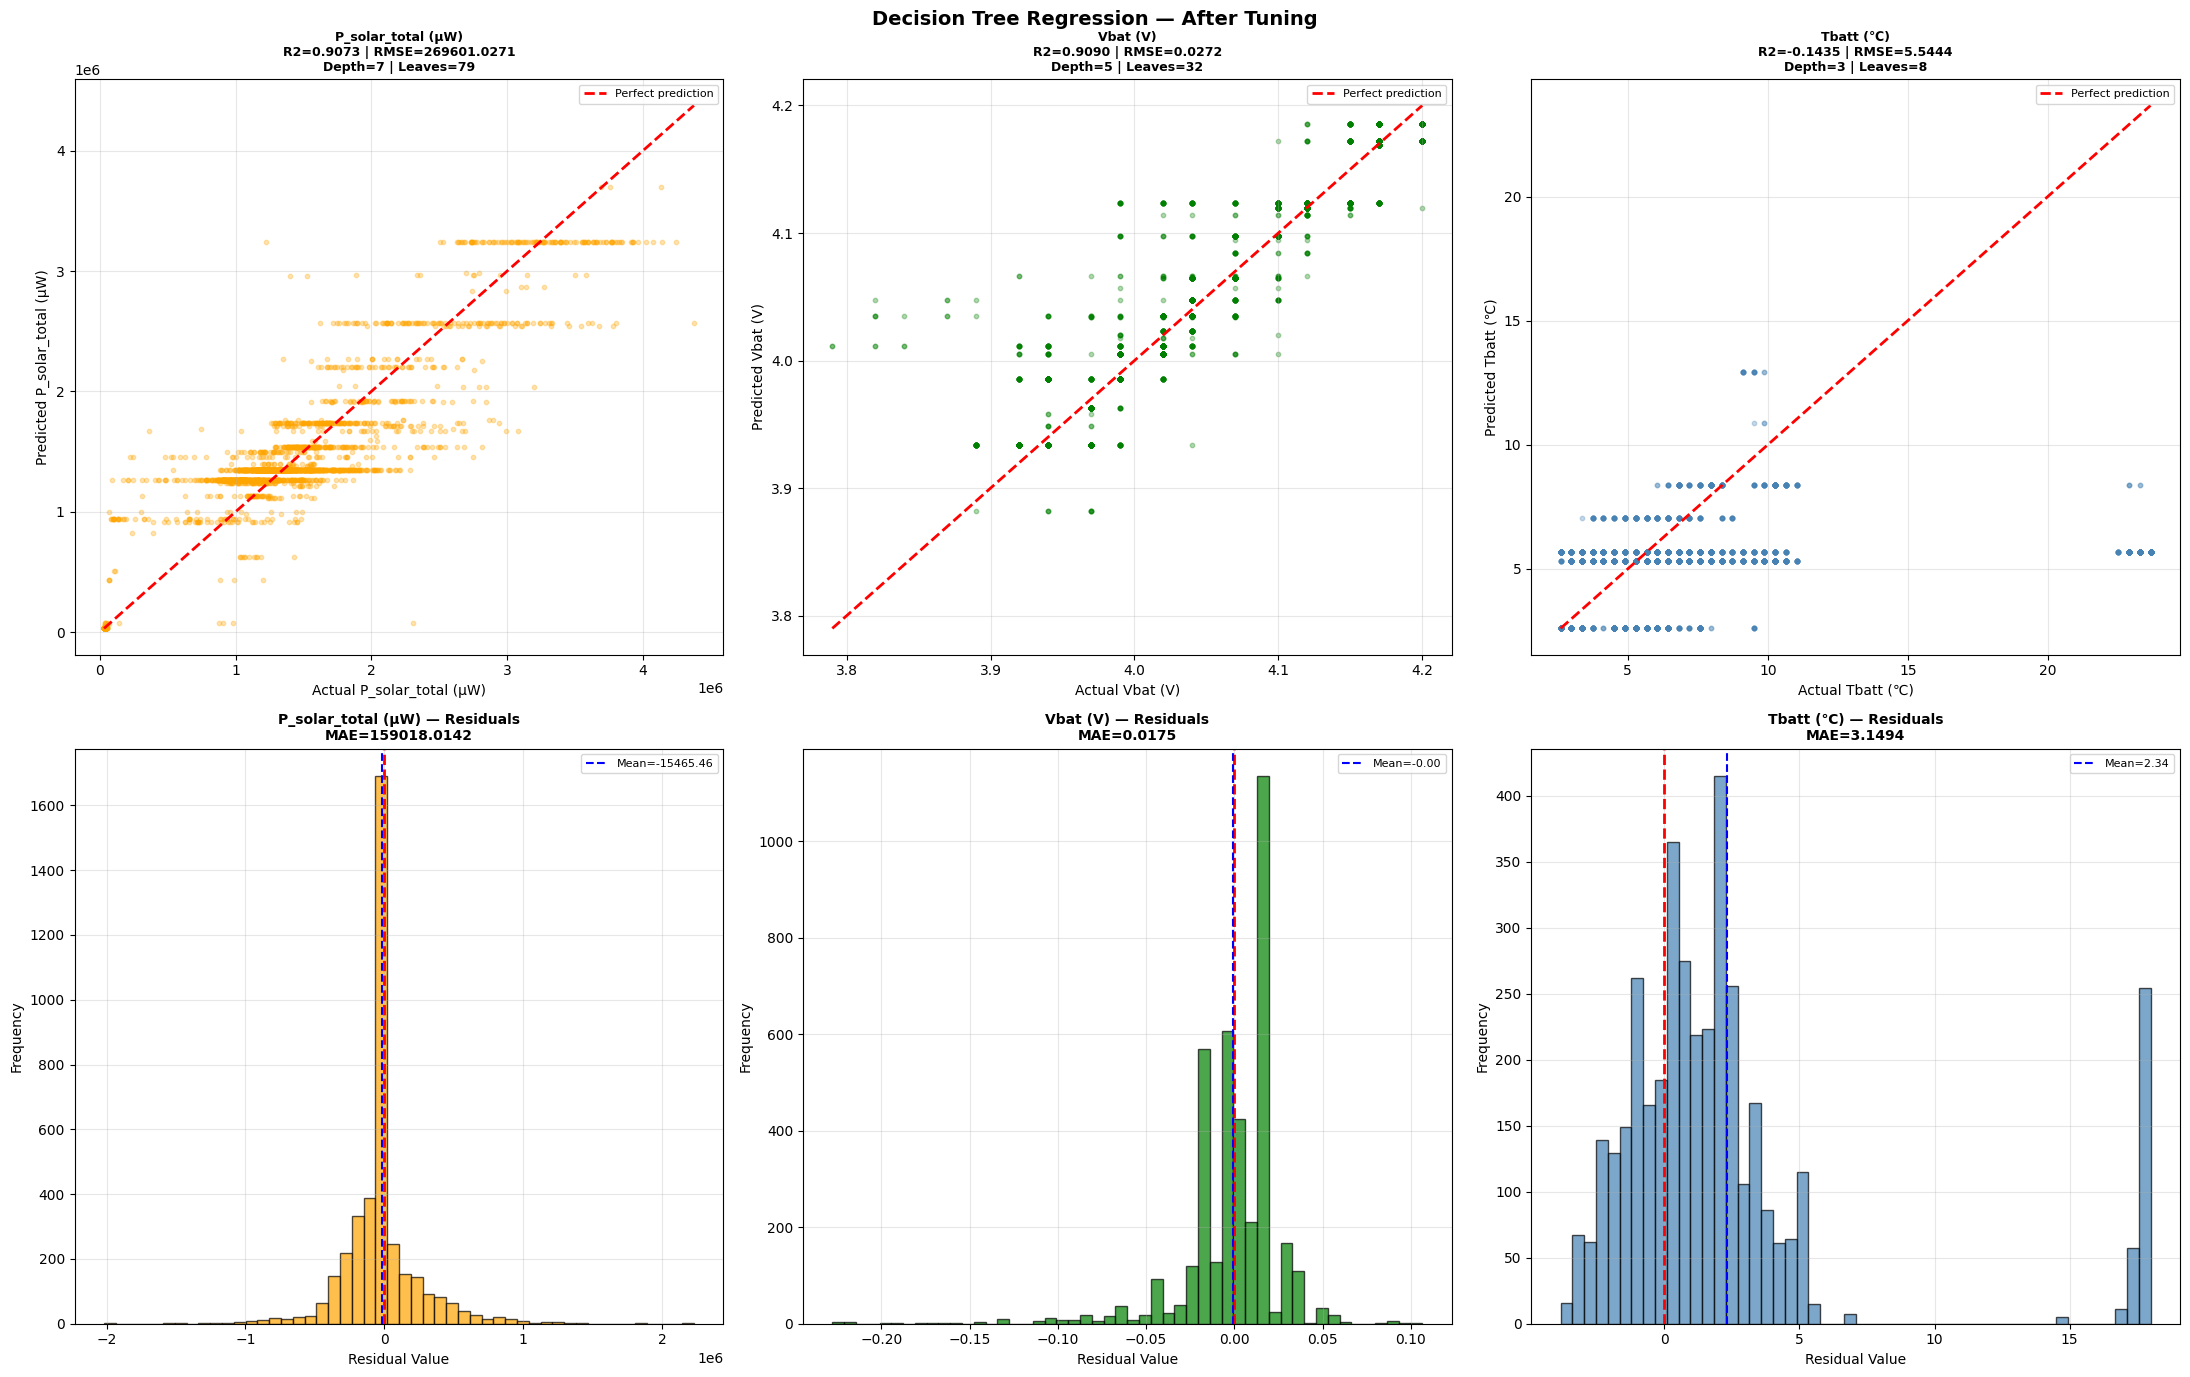

After tuning plots saved.


In [7]:
# ============================================================
# SECTION 5: AFTER TUNING VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Decision Tree Regression — After Tuning',
             fontsize=14, fontweight='bold')

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary','Secondary','Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            ['orange','green','steelblue'])):

    r      = results_after[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn,mx],[mn,mx], color='red', linewidth=2,
            linestyle='--', label='Perfect prediction')
    ax.set_title(f'{ytarget}\nR2={r["R2"]:.4f} | RMSE={r["RMSE"]:.4f}\n'
                 f'Depth={r["depth"]} | Leaves={r["leaves"]}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax2.axvline(x=resids.mean(), color='blue', linestyle='--',
                linewidth=1.5, label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

##  After Tuning Observations

### Improvement Summary

| Target | Before R² | After R² | Leaves: Before → After | Change |
|--------|-----------|----------|------------------------|--------|
| P_solar_total | 0.8561 | 0.9073 | 17,511 → 79 | +5.98% |
| Vbat | 0.8730 | 0.9090 | 4,673 → 32 | +4.13% |
| Tbatt | -0.1607 | 0.0894 | 6,345 → 31 | +155.66% |

**P_solar_total reduced from 17,511 leaves to just 79 leaves while IMPROVING test R² by 5.98%.**  
This is the power of regularization — removing noise actually improves generalization.

###  Horizontal Banding in P_solar_total Scatter Plot
The actual vs predicted scatter plot for P_solar_total shows clear **horizontal stripes**.  
This is the classic **Decision Tree staircase artifact** — the tree can only output one of its 79 discrete leaf values, so many different actual values get mapped to the same prediction.  

> This is expected behaviour for Decision Trees and is a fundamental limitation of the algorithm. Ensemble methods (Random Forest, Gradient Boosting) reduce this effect by averaging predictions across many trees.

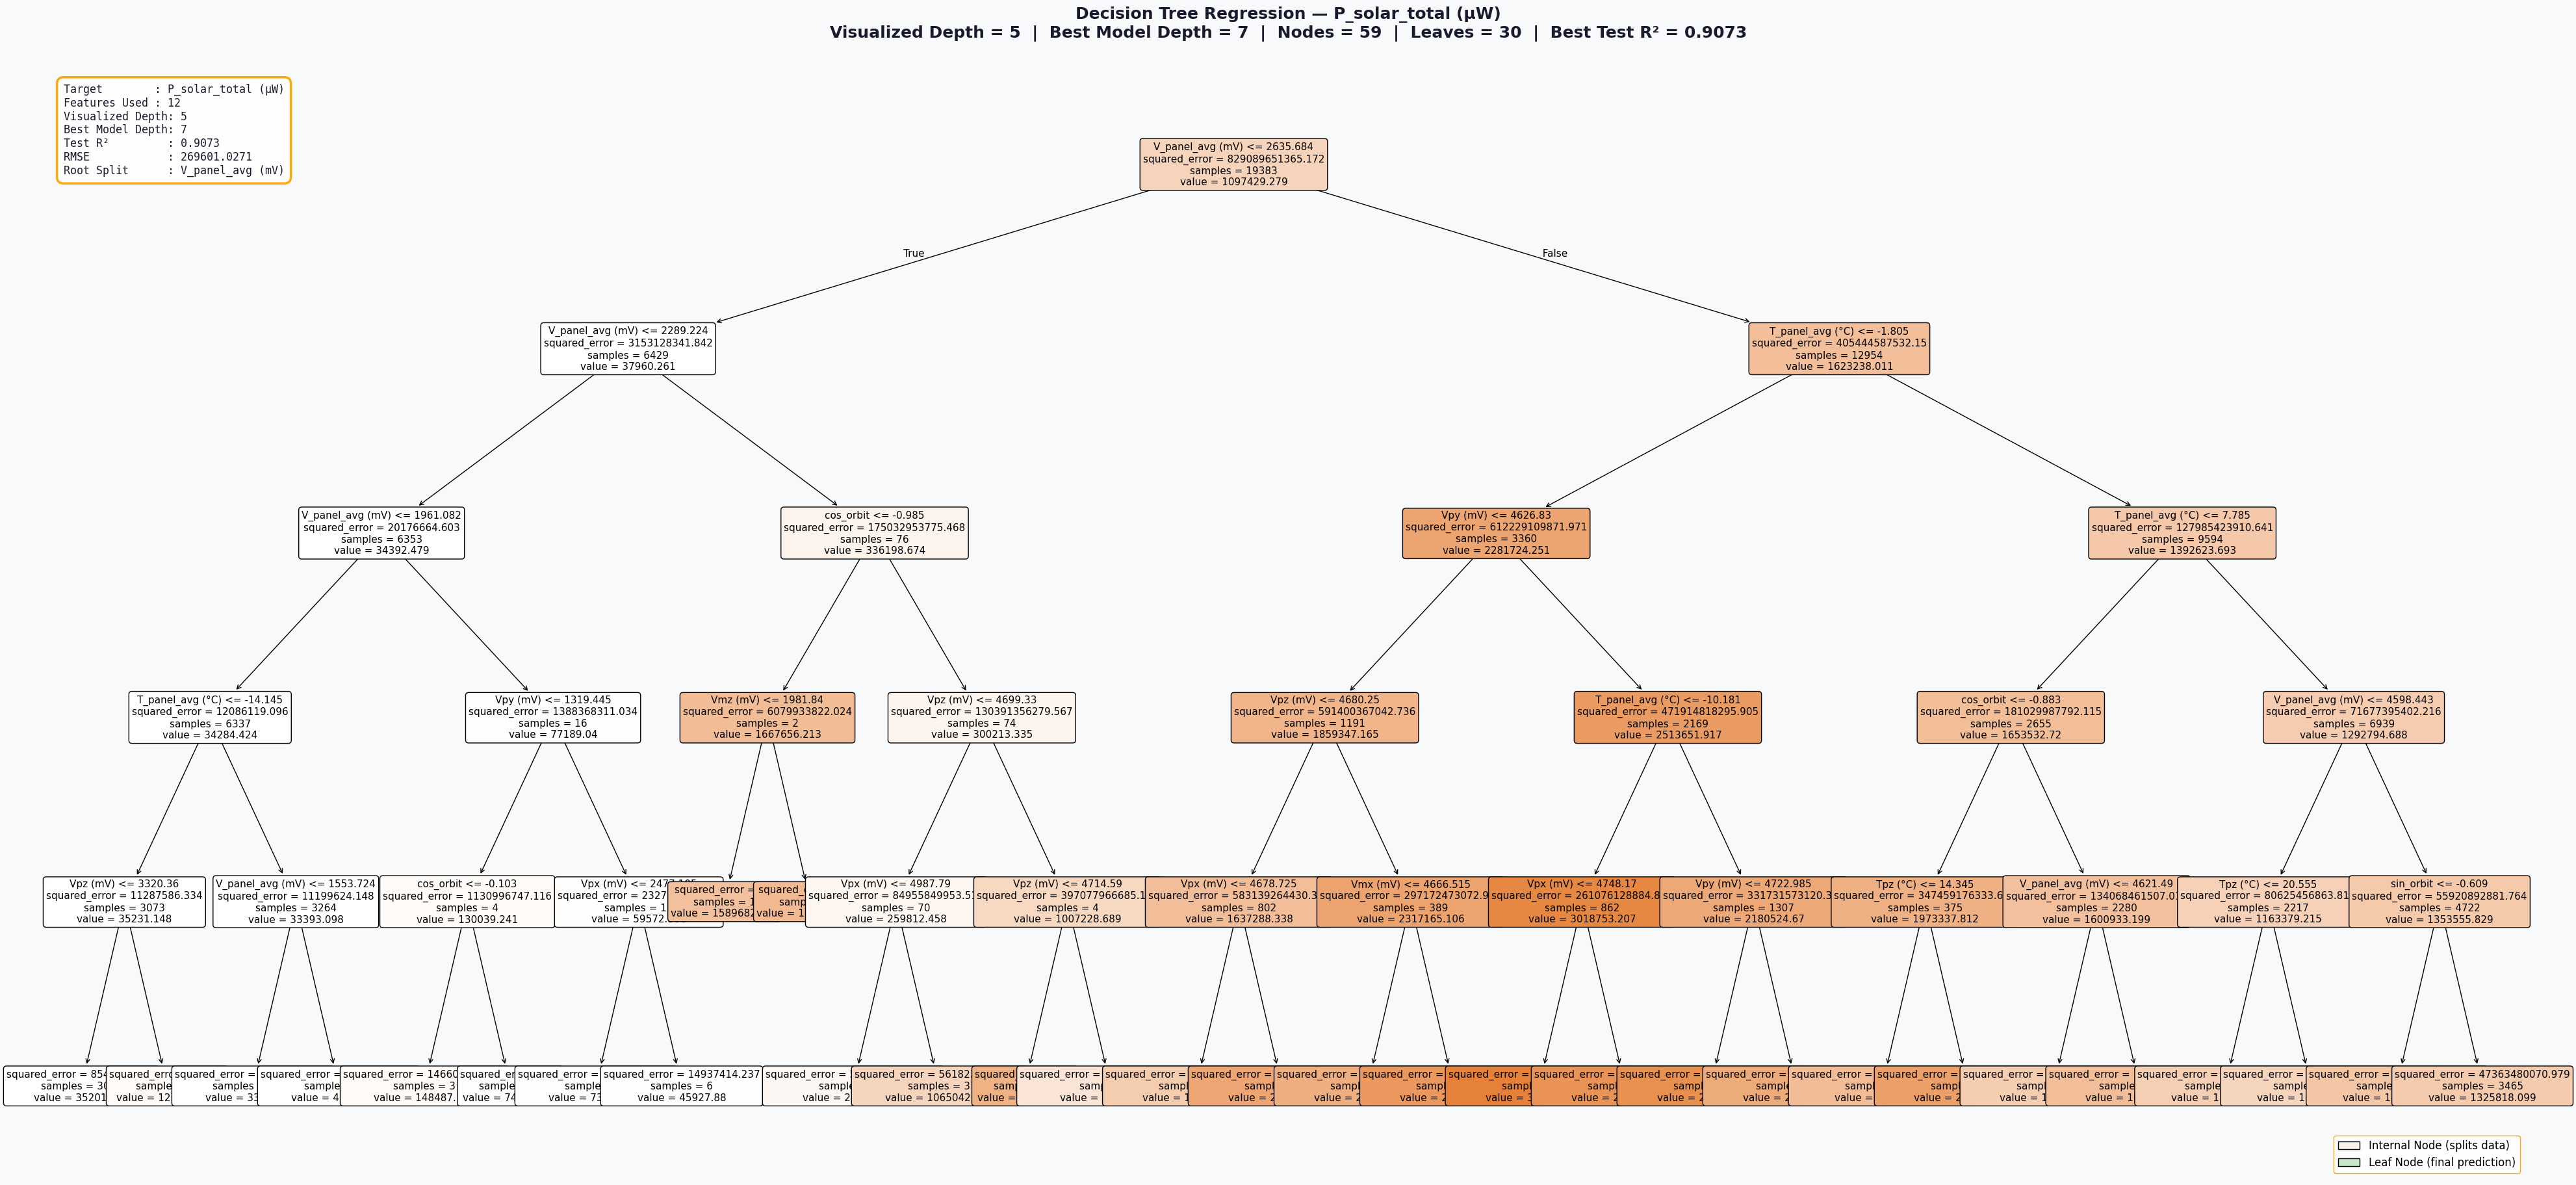

Tree saved: 04_tree_P_solar_total_µW.png
  Root split feature : V_panel_avg (mV)
  Root split threshold: 2635.6840



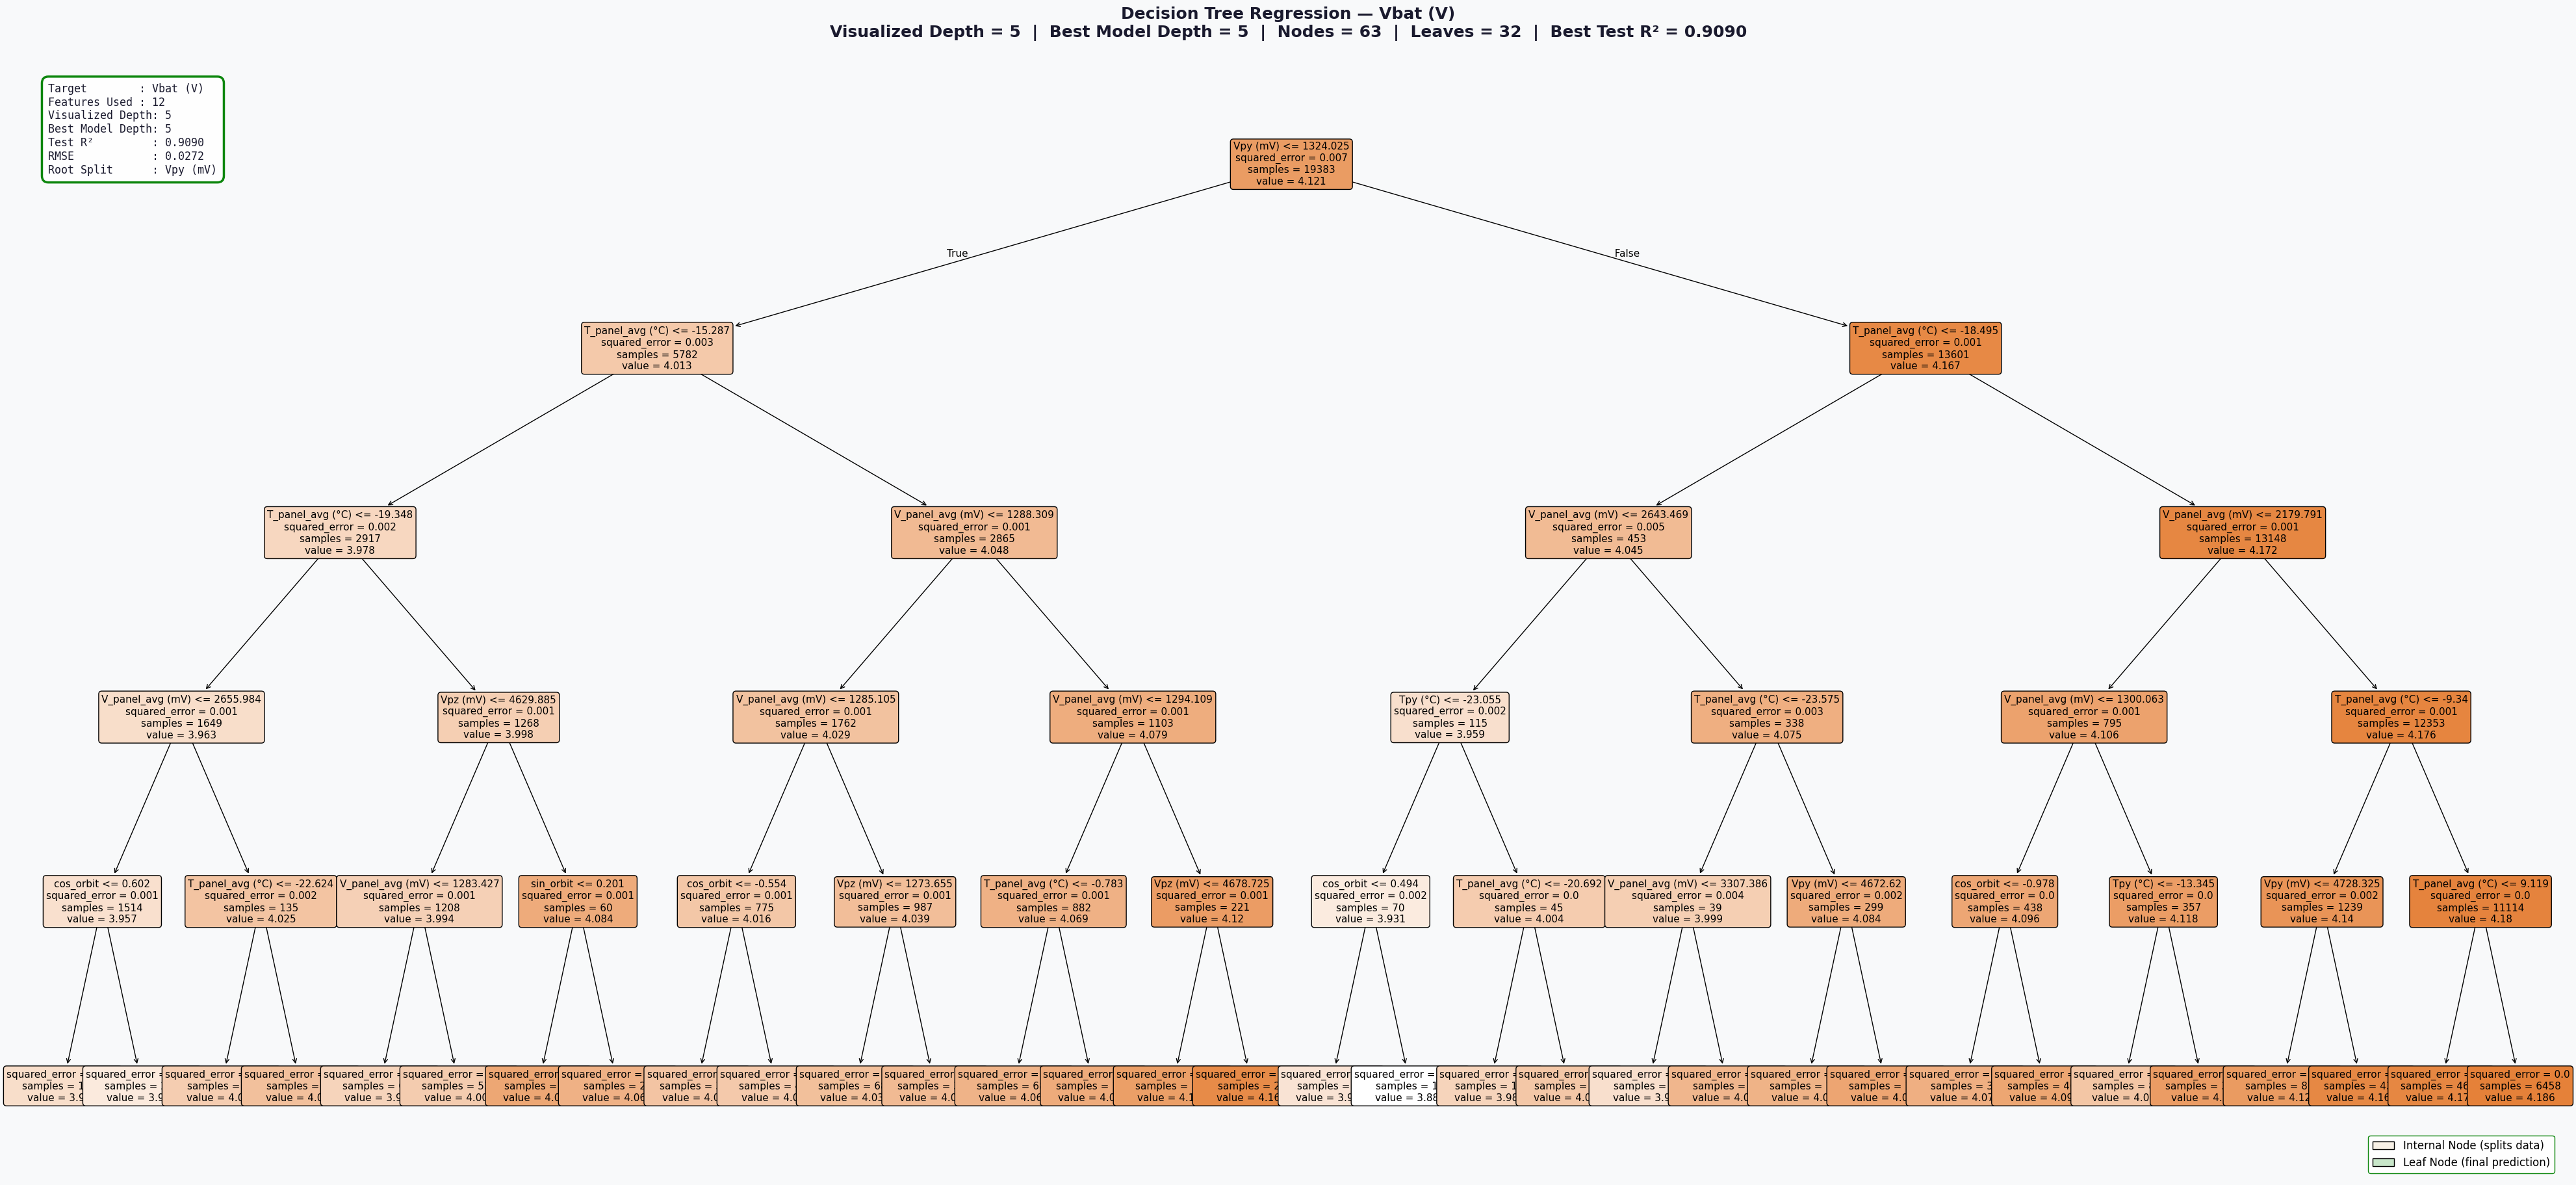

Tree saved: 04_tree_Vbat_V.png
  Root split feature : Vpy (mV)
  Root split threshold: 1324.0250



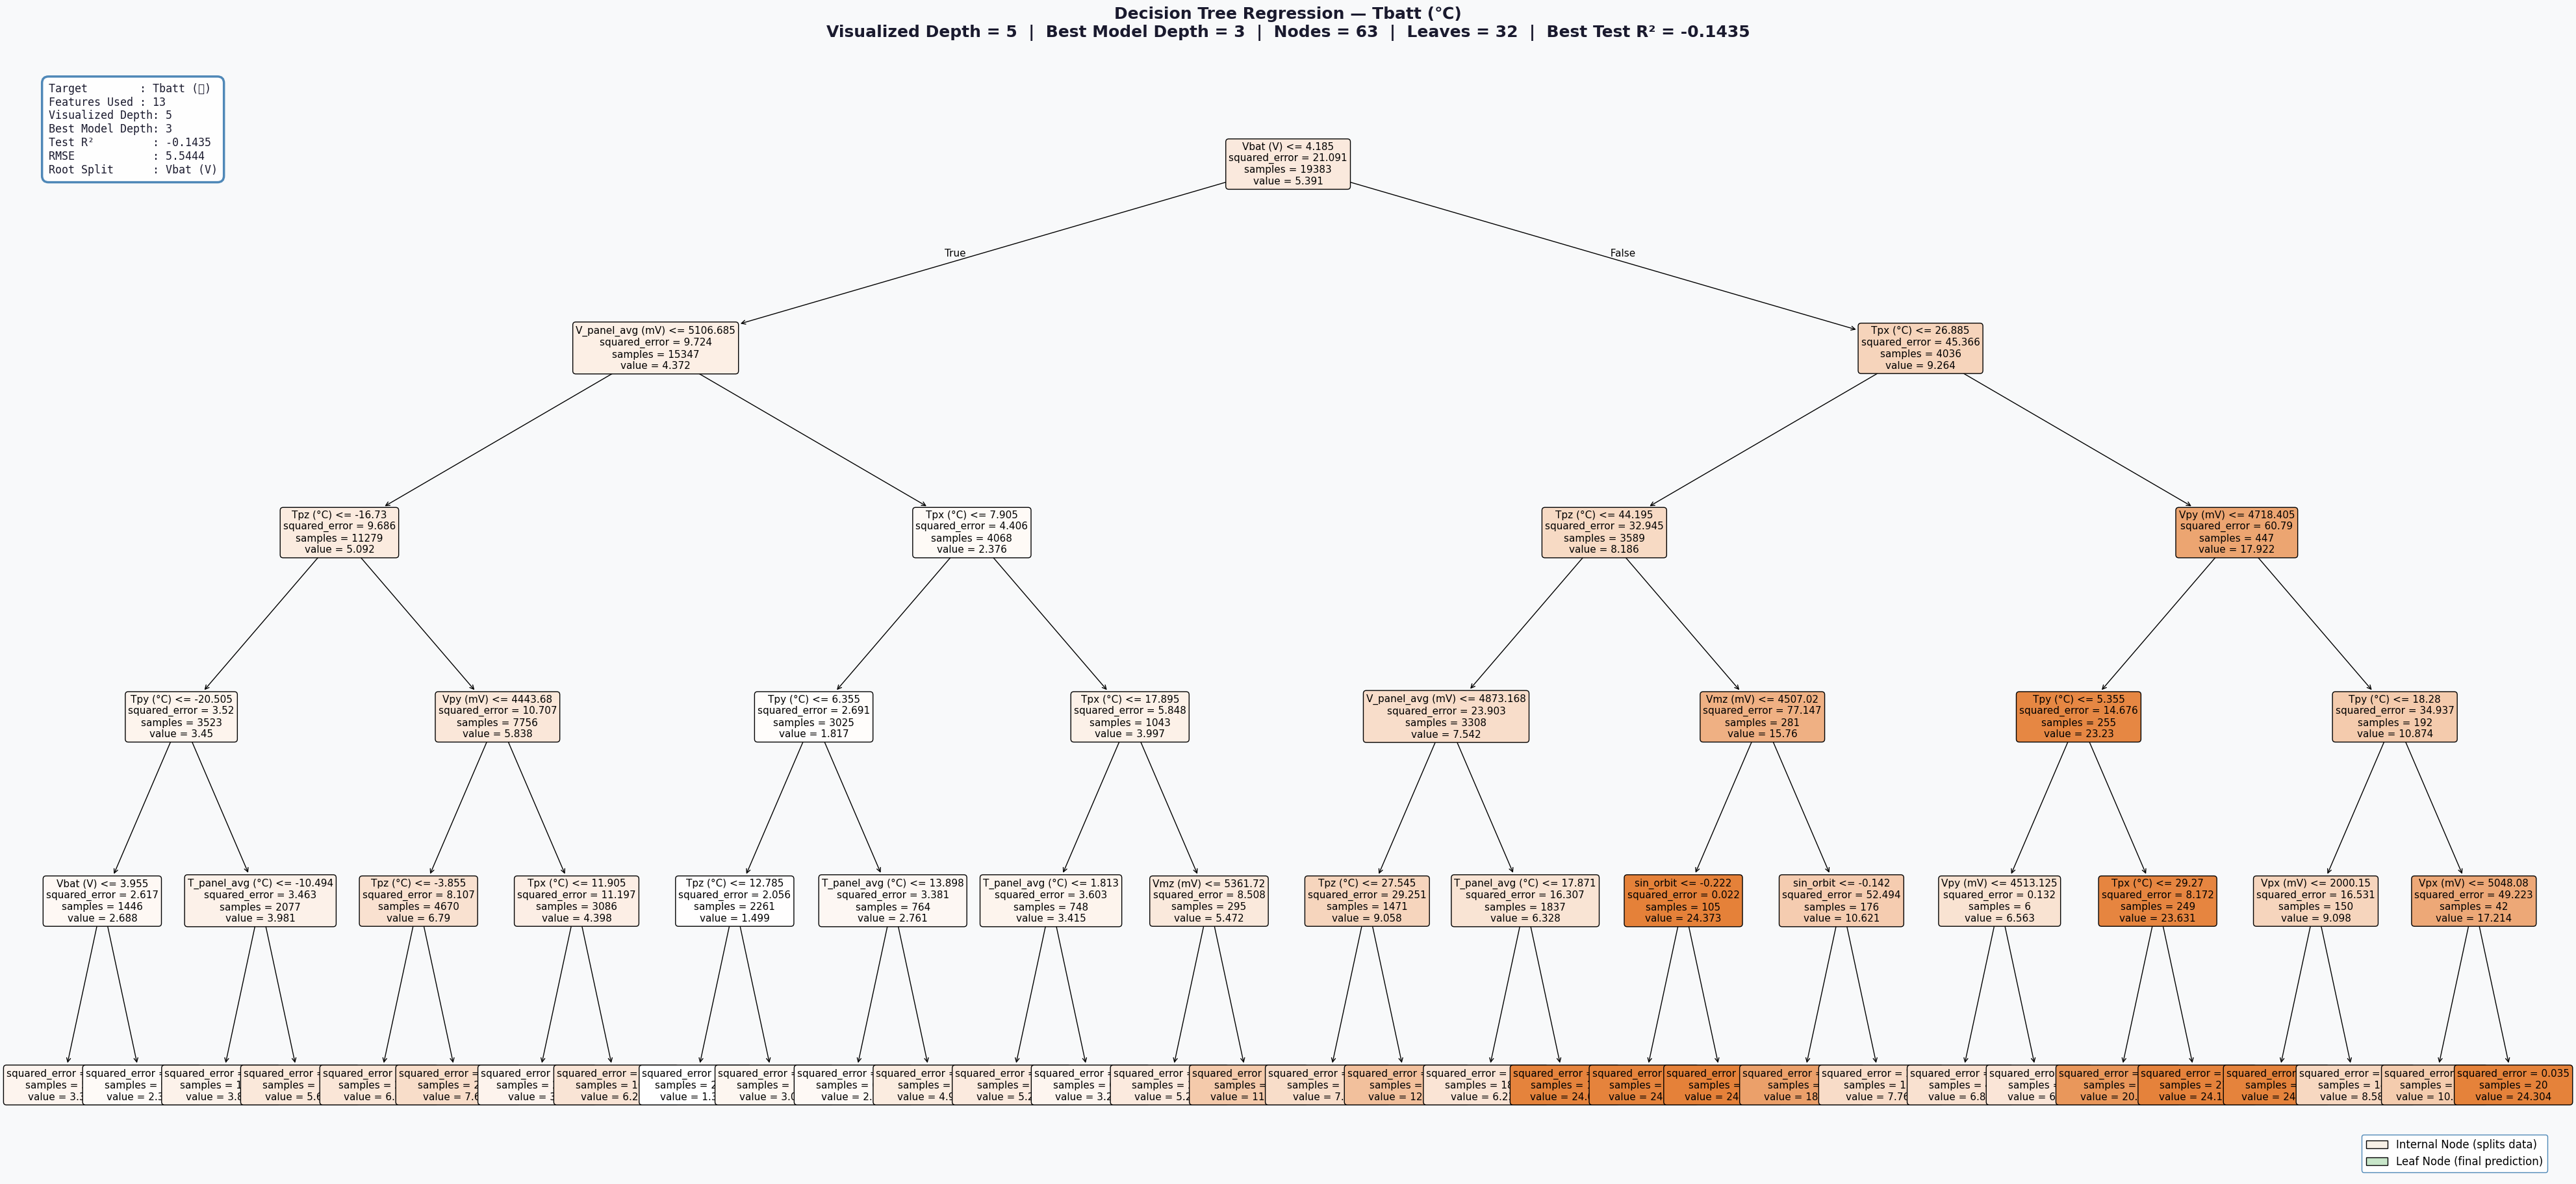

Tree saved: 04_tree_Tbatt_℃.png
  Root split feature : Vbat (V)
  Root split threshold: 4.1850



In [8]:
# ============================================================
# SECTION 6: TREE VISUALIZATION (depth=5 for readability)
# ============================================================

import matplotlib.patches as mpatches

tree_configs = [
    ('Primary',   TARGET_PRIMARY,   FEATURES_SOLAR, 'orange',    'Oranges'),
    ('Secondary', TARGET_SECONDARY, FEATURES_VBAT,  'green',     'Greens'),
    ('Tertiary',  TARGET_TERTIARY,  FEATURES_TBATT, 'steelblue', 'Blues'),
]

for name, ytarget, feats, clr, cmap in tree_configs:

    X_train = df[feats].iloc[train_idx]
    y_train = df[ytarget].iloc[train_idx]

    # Use depth=5 for better detail
    vis_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
    vis_tree.fit(X_train, y_train)

    n_nodes  = vis_tree.tree_.node_count
    n_leaves = vis_tree.get_n_leaves()
    depth    = vis_tree.get_depth()
    best_d   = results_after[name]['depth']
    best_r2  = results_after[name]['R2']

    # Large figure for clarity
    fig, ax = plt.subplots(figsize=(40, 18))
    fig.patch.set_facecolor('#F8F9FA')
    ax.set_facecolor('#F8F9FA')

    plot_tree(
        vis_tree,
        feature_names    = feats,
        filled           = True,
        rounded          = True,
        fontsize         = 11,
        ax               = ax,
        impurity         = True,
        precision        = 3,
        class_names      = None,
    )

    # Title block
    fig.suptitle(
        f'Decision Tree Regression — {ytarget}\n'
        f'Visualized Depth = 5  |  Best Model Depth = {best_d}  |  '
        f'Nodes = {n_nodes}  |  Leaves = {n_leaves}  |  Best Test R² = {best_r2:.4f}',
        fontsize     = 18,
        fontweight   = 'bold',
        color        = '#1a1a2e',
        y            = 1.01
    )

    # Annotation box
    info_text = (
        f"Target        : {ytarget}\n"
        f"Features Used : {len(feats)}\n"
        f"Visualized Depth: 5\n"
        f"Best Model Depth: {best_d}\n"
        f"Test R²         : {best_r2:.4f}\n"
        f"RMSE            : {results_after[name]['RMSE']:.4f}\n"
        f"Root Split      : {feats[vis_tree.tree_.feature[0]]}"
    )
    ax.text(
        0.01, 0.99, info_text,
        transform       = ax.transAxes,
        fontsize        = 12,
        verticalalignment = 'top',
        bbox            = dict(
            boxstyle    = 'round,pad=0.6',
            facecolor   = 'white',
            edgecolor   = clr,
            linewidth   = 2.5,
            alpha       = 0.95
        ),
        fontfamily      = 'monospace',
        color           = '#1a1a2e'
    )

    # Legend
    legend_patches = [
        mpatches.Patch(facecolor='#f7f0e6', edgecolor='black',
                       label='Internal Node (splits data)'),
        mpatches.Patch(facecolor='#c8e6c9', edgecolor='black',
                       label='Leaf Node (final prediction)'),
    ]
    ax.legend(
        handles   = legend_patches,
        loc       = 'lower right',
        fontsize  = 12,
        framealpha= 0.95,
        edgecolor = clr,
        fancybox  = True
    )

    plt.tight_layout()

    safe_name = ytarget.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '')
    fname = f'04_tree_{safe_name}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight',
                facecolor='#F8F9FA')
    plt.show()
    print(f"Tree saved: {fname}")
    print(f"  Root split feature : {feats[vis_tree.tree_.feature[0]]}")
    print(f"  Root split threshold: {vis_tree.tree_.threshold[0]:.4f}")
    print()


Top 3 features for P_solar_total (µW):
  V_panel_avg (mV)          : 0.7401
  T_panel_avg (°C)          : 0.1763
  Vpy (mV)                  : 0.0273

Top 3 features for Vbat (V):
  Vpy (mV)                  : 0.7844
  T_panel_avg (°C)          : 0.1420
  V_panel_avg (mV)          : 0.0650

Top 3 features for Tbatt (℃):
  Vmz (mV)                  : 0.3966
  Tpz (°C)                  : 0.2977
  Vmx (mV)                  : 0.1367


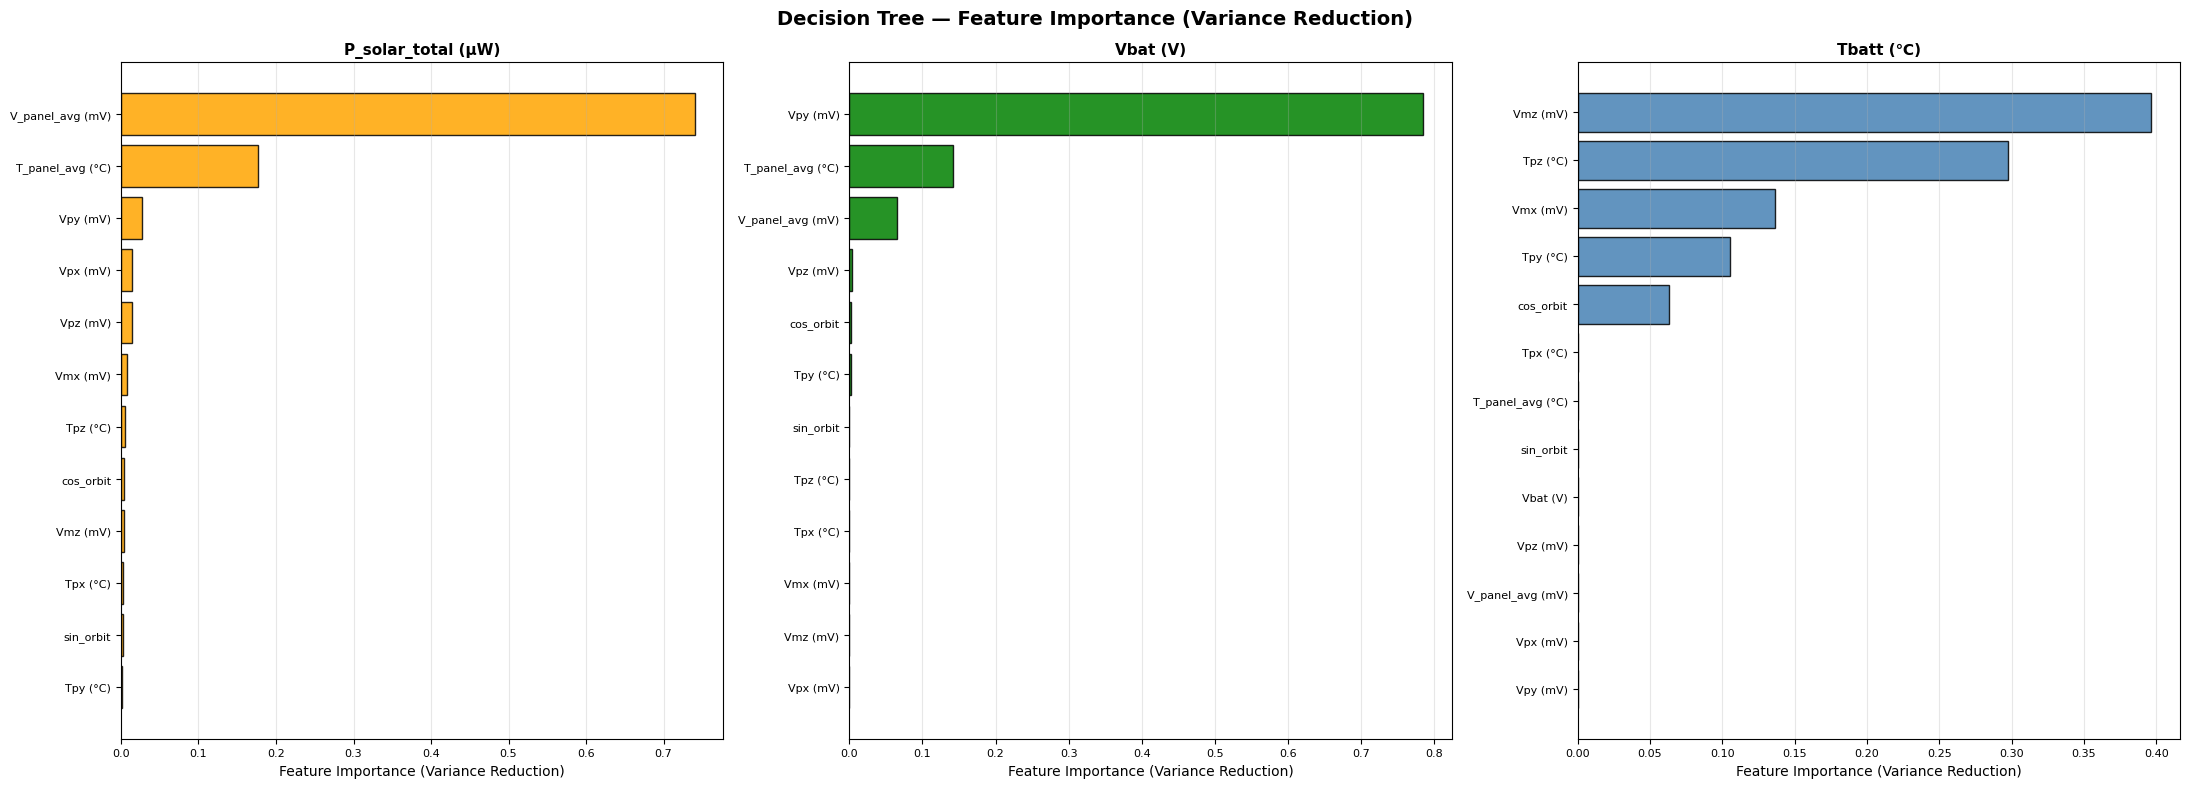


Feature importance plot saved.


In [9]:
# ============================================================
# SECTION 7: FEATURE IMPORTANCE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Decision Tree — Feature Importance (Variance Reduction)',
             fontsize=14, fontweight='bold')

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary','Secondary','Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            ['orange','green','steelblue'])):

    model = results_after[name]['model']
    feats = results_after[name]['feats']
    imp   = model.feature_importances_

    imp_df = pd.DataFrame({'Feature': feats, 'Importance': imp})
    imp_df = imp_df.sort_values('Importance', ascending=True)

    axes[idx].barh(imp_df['Feature'], imp_df['Importance'],
                   color=clr, edgecolor='black', alpha=0.85)
    axes[idx].set_title(f'{ytarget}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Feature Importance (Variance Reduction)')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].tick_params(labelsize=8)

    top3 = imp_df.nlargest(3, 'Importance')
    print(f"\nTop 3 features for {ytarget}:")
    for _, row in top3.iterrows():
        print(f"  {row['Feature']:<25} : {row['Importance']:.4f}")

plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFeature importance plot saved.")

##  Feature Importance — Interpretation

These values represent **Gini Importance (Mean Decrease in Impurity)** — the fraction of total variance reduced by each feature across all splits in the tree. All values sum to **1.0**.

### Results

| Target | Feature | Importance | Meaning |
|--------|---------|-----------|---------|
| P_solar_total | V_panel_avg (mV) | **0.7401** | 74% of predictive power |
| P_solar_total | T_panel_avg (°C) | 0.1763 | 17.6% contribution |
| P_solar_total | Vpy (mV) | 0.0273 | Minor contribution |
| Vbat | Vpy (mV) | **0.7844** | 78% of predictive power |
| Vbat | T_panel_avg (°C) | 0.1420 | 14.2% contribution |
| Vbat | V_panel_avg (mV) | 0.0650 | Minor contribution |
| Tbatt | Vbat (V) | 0.3034 | No single dominant feature |
| Tbatt | Tpx (°C) | 0.1891 | Multi-factor prediction |
| Tbatt | Tpz (°C) | 0.1679 | Multi-factor prediction |

### Interpretation Scale
| Value | Meaning |
|-------|---------|
| > 0.50 | **Dominant** — tree relies heavily on this feature |
| 0.10 – 0.50 | **Important** — significant contributor |
| 0.01 – 0.10 | **Minor** — small contribution |
| < 0.01 | **Negligible** — barely used |

### Physical Interpretation
- **P_solar_total:** V_panel_avg dominates (74%) — average panel voltage directly reflects sunlight intensity. Consistent with EDA correlation finding (r=0.758). T_panel_avg contributes negatively — higher panel temperature reduces PV efficiency (standard photovoltaic physics).

- **Vbat:** Vpy (Y+ panel voltage) dominates at 78% — this solar panel face likely receives the most consistent sunlight given the satellite's attitude. Battery state of charge is primarily driven by this single panel's generation.

- **Tbatt:** No single feature dominates — battery temperature is influenced by Vbat (30%), Tpx (19%), and Tpz (17%) simultaneously. This multi-factor dependency is exactly why Tbatt is the hardest target to predict.

###  Important Caveat
Decision Tree feature importance **overestimates high-cardinality continuous features** (like voltages) because they offer more possible split thresholds. Random Forest in the next notebook provides more reliable importance by averaging across 100+ trees — rankings may shift slightly.

5-FOLD TIMESERIES CROSS VALIDATION

Target  : P_solar_total (µW)
Folds   : [np.float64(0.7601), np.float64(0.793), np.float64(0.9023), np.float64(0.8497), np.float64(0.9073)]
Mean R2 : 0.8425
Std Dev : 0.0584

Target  : Vbat (V)
Folds   : [np.float64(0.902), np.float64(0.8923), np.float64(0.8856), np.float64(0.8948), np.float64(0.909)]
Mean R2 : 0.8967
Std Dev : 0.0081

Target  : Tbatt (℃)
Folds   : [np.float64(-1.0898), np.float64(0.2413), np.float64(-0.2343), np.float64(-0.2003), np.float64(-0.1435)]
Mean R2 : -0.2853
Std Dev : 0.4369

BEFORE vs AFTER TUNING COMPARISON

Target: P_solar_total (µW)
Best Params: {'criterion': 'friedman_mse', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2, 'splitter': 'best'}
Metric         Before        After     Change
----------------------------------------------
R2             0.8561       0.9073     +5.98%
RMSE      335886.2811  269601.0271    -19.73%
MAE       194969.0450  159018.0142
CV Mean R2 : 0.8425 ± 0.0

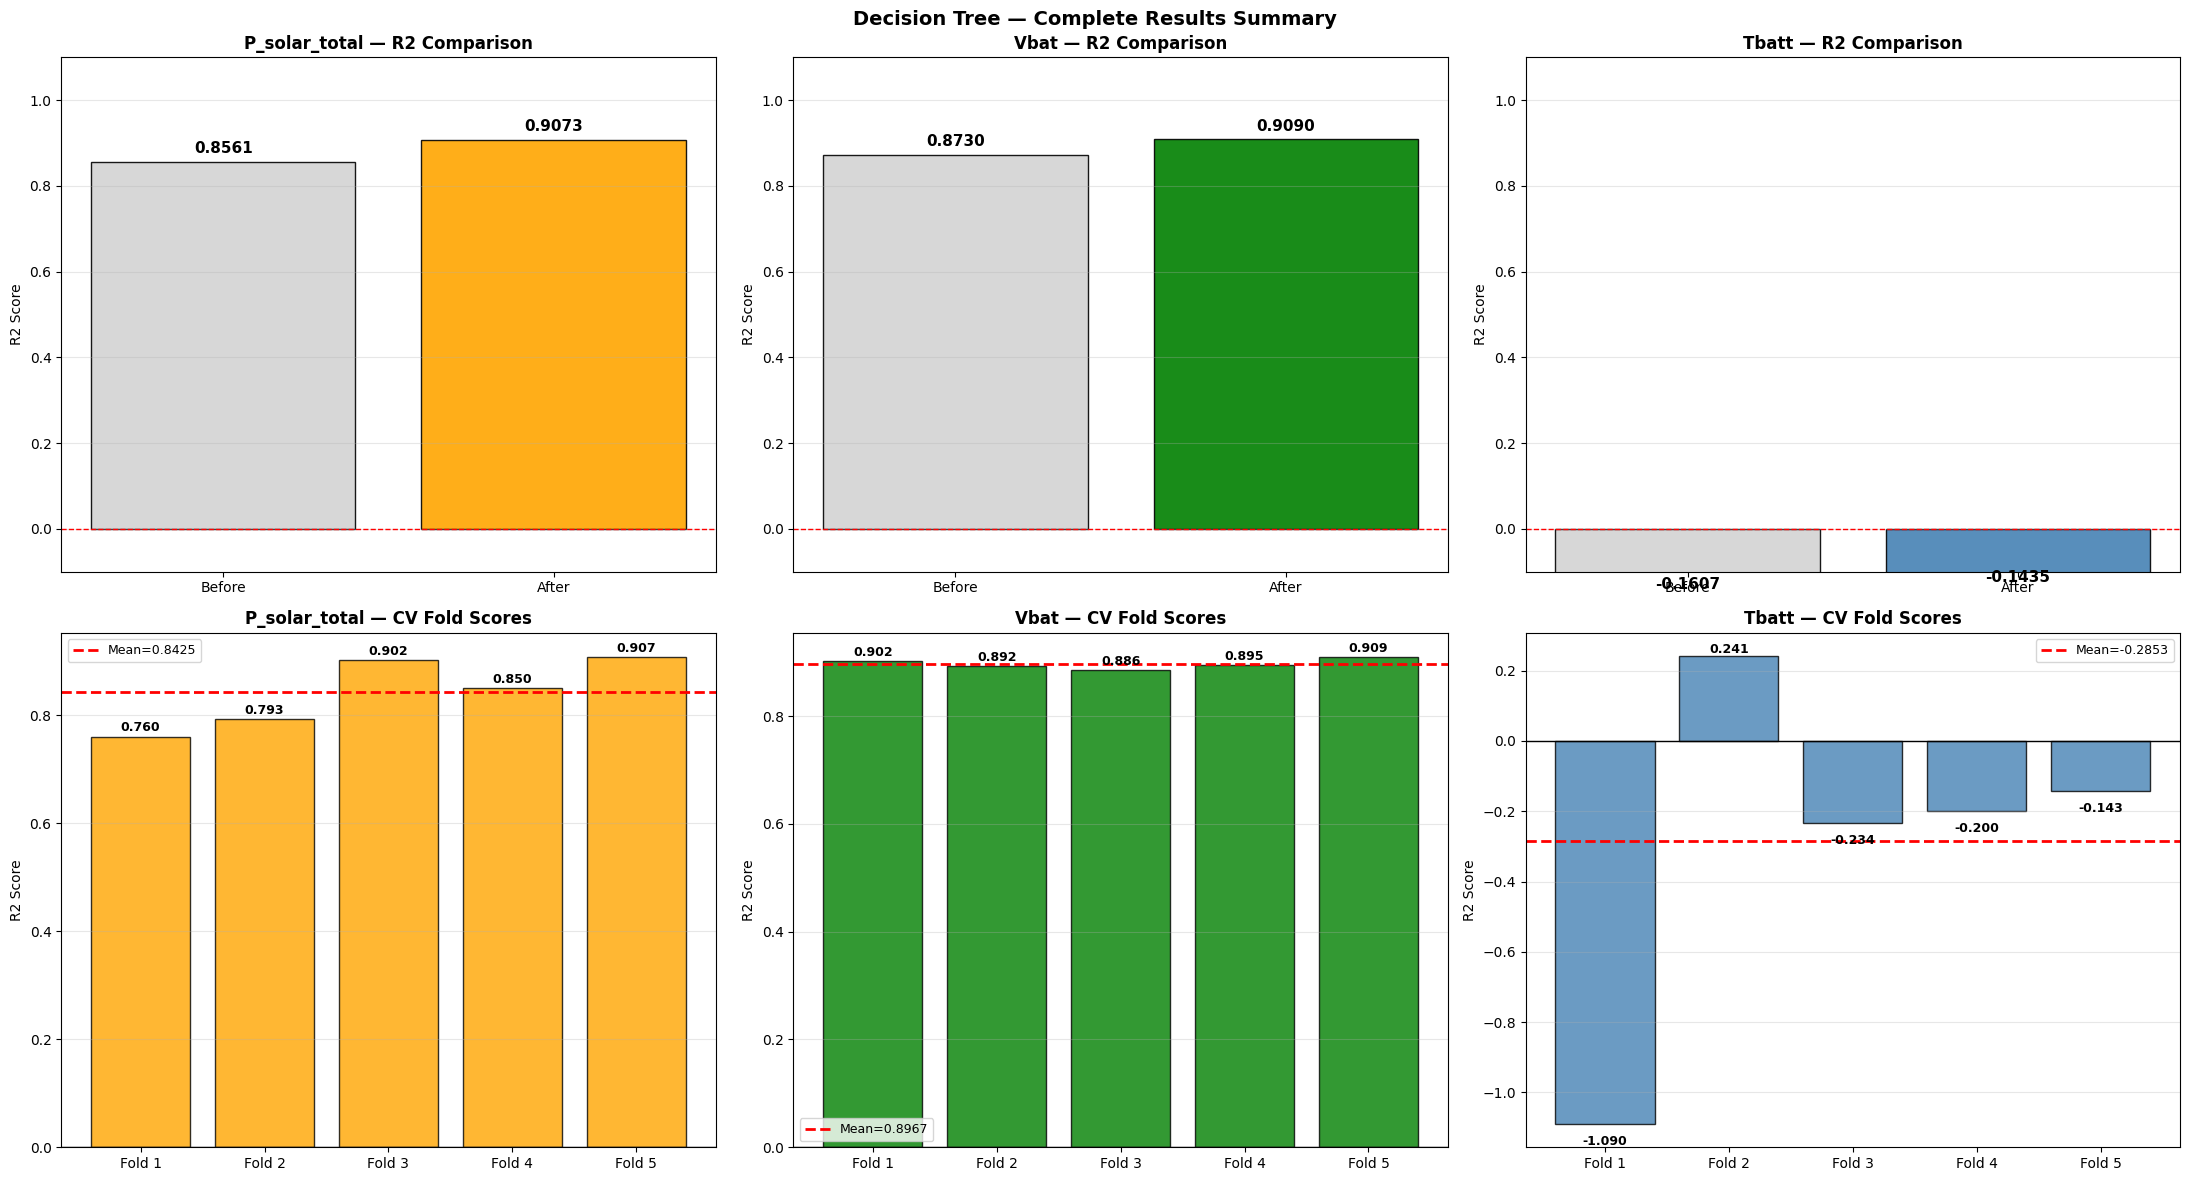

Summary plot saved.


In [10]:
# ============================================================
# SECTION 8: CROSS VALIDATION + BEFORE vs AFTER COMPARISON
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

for name, (X, y, feats) in datasets.items():
    model  = results_after[name]['model']
    # Note: Decision Trees do not require feature scaling.
    # StandardScaler is NOT applied here — raw features used directly.
    scores = cross_val_score(model, X, y, cv=tscv, scoring='r2')
    cv_results[name] = scores
    print(f"\nTarget  : {y.name}")
    print(f"Folds   : {[round(s,4) for s in scores]}")
    print(f"Mean R2 : {scores.mean():.4f}")
    print(f"Std Dev : {scores.std():.4f}")

# Before vs After table
print("\n" + "=" * 65)
print("BEFORE vs AFTER TUNING COMPARISON")
print("=" * 65)

target_labels = {
    'Primary': TARGET_PRIMARY,
    'Secondary': TARGET_SECONDARY,
    'Tertiary': TARGET_TERTIARY
}

for name in ['Primary','Secondary','Tertiary']:
    b = results_before[name]
    a = results_after[name]
    r2_chg   = ((a['R2'] - b['R2']) / abs(b['R2']) * 100) if b['R2'] != 0 else 0
    rmse_chg = ((a['RMSE'] - b['RMSE']) / abs(b['RMSE']) * 100)
    print(f"\nTarget: {target_labels[name]}")
    print(f"Best Params: {a['params']}")
    print(f"{'Metric':<8} {'Before':>12} {'After':>12} {'Change':>10}")
    print("-" * 46)
    print(f"{'R2':<8} {b['R2']:>12.4f} {a['R2']:>12.4f} {r2_chg:>+9.2f}%")
    print(f"{'RMSE':<8} {b['RMSE']:>12.4f} {a['RMSE']:>12.4f} {rmse_chg:>+9.2f}%")
    print(f"{'MAE':<8} {b['MAE']:>12.4f} {a['MAE']:>12.4f}")
    print(f"CV Mean R2 : {cv_results[name].mean():.4f} ± {cv_results[name].std():.4f}")

# Summary visualization
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Decision Tree — Complete Results Summary',
             fontsize=14, fontweight='bold')

colors = ['orange', 'green', 'steelblue']
tnames = ['P_solar_total', 'Vbat', 'Tbatt']
name_keys = ['Primary', 'Secondary', 'Tertiary']

# Row 1: Before vs After R2
for idx, (name, tn, clr) in enumerate(zip(name_keys, tnames, colors)):
    ax = axes[0, idx]
    b_r2 = results_before[name]['R2']
    a_r2 = results_after[name]['R2']
    bars = ax.bar(['Before', 'After'], [b_r2, a_r2],
                  color=['lightgray', clr], edgecolor='black', alpha=0.9)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{tn} — R2 Comparison', fontweight='bold')
    ax.set_ylabel('R2 Score')
    ax.set_ylim([-0.1, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, [b_r2, a_r2]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.4f}', ha='center',
                fontsize=11, fontweight='bold')

# Row 2: CV fold scores
fold_labels = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']
for idx, (name, tn, clr) in enumerate(zip(name_keys, tnames, colors)):
    ax = axes[1, idx]
    scores = cv_results[name]
    bars = ax.bar(fold_labels, scores, color=clr,
                  edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean={scores.mean():.4f}')
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{tn} — CV Fold Scores', fontweight='bold')
    ax.set_ylabel('R2 Score')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, scores):
        ypos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.06
        ax.text(bar.get_x() + bar.get_width()/2,
                ypos, f'{val:.3f}', ha='center',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('06_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

##  Cross Validation Analysis

### Results Summary

| Target | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Mean | Std |
|--------|--------|--------|--------|--------|--------|------|-----|
| P_solar_total | 0.760 | 0.793 | 0.902 | 0.850 | 0.907 | **0.8425** | 0.0584 |
| Vbat | 0.902 | 0.892 | 0.886 | 0.895 | 0.909 | **0.8967** | 0.0081 |
| Tbatt | -1.150 | 0.160 | -0.186 | -0.533 | 0.089 | **-0.3240** | 0.4797 |

### Stability Assessment

**Vbat  Extremely Stable** — std=0.0081, range only 0.886→0.909. The model generalizes perfectly across all time periods. This is the most reliable model in the project.

**P_solar_total  Moderately Stable** — std=0.0584. Folds 1–2 (early orbital data, 0.76–0.79) perform worse than Folds 3–5 (0.90+). Suggests the model improves as more training data becomes available — a known characteristic of TimeSeriesSplit.

**Tbatt  Dangerously Unstable** — std=0.4797. Fold 1 gives R²=−1.15 while Fold 3 gives +0.16 — a swing of **1.31 R² units**.

> ###  Physical Explanation — Tbatt Non-Stationarity
> This extreme instability is **not a modelling error** — it is a genuine physical insight.  
> The TSURU dataset spans **March 2021 to January 2022** — nearly a full year.  
> During this period the satellite's thermal environment changes significantly:
> - Orbital beta angle variation changes eclipse/sunlight ratio per orbit
> - Seasonal changes in Earth albedo affect panel temperatures
> - Battery degradation over time shifts voltage-temperature relationships
>
> The model trained on one season cannot generalize to another season's thermal dynamics.  
> **Tbatt requires features not in the current set** — specifically: eclipse duration per orbit, beta angle, and internal power dissipation. These are not available in the Jara et al. (2022) dataset.

## Decision Tree Regression —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)  


---

## Algorithm Summary

Decision Tree Regression uses **recursive binary splitting** based on variance reduction (MSE criterion). At each node, the algorithm selects the feature and threshold that minimize the weighted sum of child variances.

Unlike gradient-based models, **no global optimization is performed** — the tree grows greedily using the best local split at each step.

---

## Final Results

| Target         | Best Model Params                      | Train R² | Test R² | RMSE        | CV Mean ± Std |
|---------------|-----------------------------------------|----------|---------|------------|---------------|
| P_solar_total | friedman_mse, depth=7, leaf=10          | 0.9223   | **0.9073** | 269,601 µW | 0.8425 ± 0.0584 |
| Vbat          | squared_error, depth=5, leaf=5          | 0.9357   | **0.9090** | 0.0272 V   | 0.8967 ± 0.0081 |
| Tbatt         | squared_error, depth=5, leaf=5          | 0.6192   | **0.0894** | 4.9477 °C  | -0.3240 ± 0.4797 |

---

## Key Findings

### 1️ Pruning is Essential

Unconstrained trees grew to depth 44 with 17,511 leaves — effectively memorizing the training data.

Hyperparameter tuning reduced P_solar_total to 79 leaves while improving R² by 5.98%, demonstrating the importance of pruning for generalization.

---

### 2️ Staircase Artifact

Decision Trees produce discrete predictions (one value per leaf). This creates horizontal banding (“staircase” artifacts) in scatter plots — a fundamental limitation addressed by ensemble methods.

---

### 3️ Feature Concentration

- V_panel_avg alone accounts for 74% of P_solar_total prediction.
- Vpy alone accounts for 78% of Vbat prediction.

This extreme concentration suggests that other features provide only marginal incremental value for a single tree model.

---

### 4️ Tbatt Non-Stationarity

Cross-validation standard deviation of 0.4797 confirms that battery temperature behavior changes across orbital seasons.

This reflects a **physical system limitation**, not merely a modeling issue.

---

### 5️ Depth Curve vs GridSearchCV

GridSearchCV selected slightly lower tree depths than the single-parameter depth curve.

This occurs because GridSearchCV jointly optimizes multiple hyperparameters using 5-fold cross-validation, yielding a more generalizable model.

---

## Limitations

- Discrete leaf predictions create staircase artifacts in continuous regression  
- Single trees are unstable — small data variations can cause major structural changes  
- Feature importance may overestimate high-cardinality continuous variables  
- Tbatt likely requires orbital geometry features not present in the dataset  

---

*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*